In [1]:
#LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_recall_fscore_support

In [3]:
#DATA LOADING
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")



#   EDA   


In [4]:
print("Shape train:", train.shape)
print("Shape test:", test.shape)
print(train.info())                                                # data types and null values
print(train.describe())                                            # basic statistics
print("Nº de valores nulos:", train.isnull().sum())

# Clarifications:
  # PClass: Ticket class (1st class, 2nd class, 3rd class)
  # SibSp: Number of siblings or spouses on board
  # Parch: Number of children on board
  # Fare: Ticket price

Shape train: (891, 12)
Shape test: (418, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118

## SURVIVAL

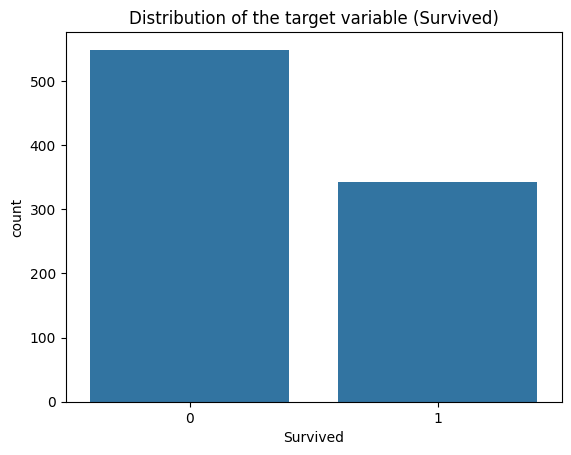

Overall survival rate: 38.38%


In [5]:
# Survival count 
sns.countplot(x="Survived", data=train)                               
plt.title("Distribution of the target variable (Survived)")    
plt.show()                                                            # 1 indicates that he survived and 0 that he did not survive         

# Percentages
survival_rate = train["Survived"].mean() * 100
print(f"Overall survival rate: {survival_rate:.2f}%")

## DISTRIBUTIONS

### Gender distribution

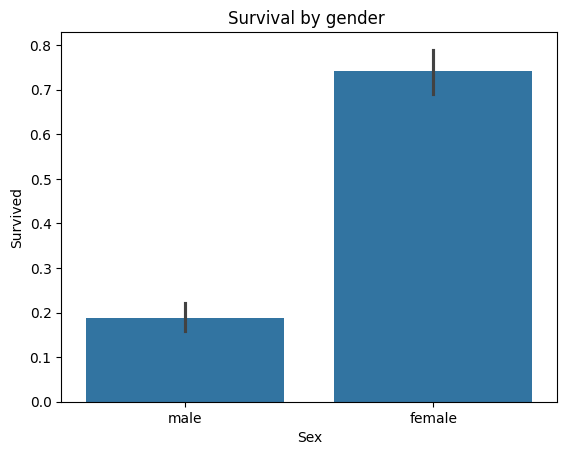

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


In [6]:
sns.barplot(x="Sex", y="Survived", data=train)
plt.title("Survival by gender ")
plt.show()

# Specific percentages
print(train.groupby("Sex")["Survived"].mean()*100)

### Ticket class distribution

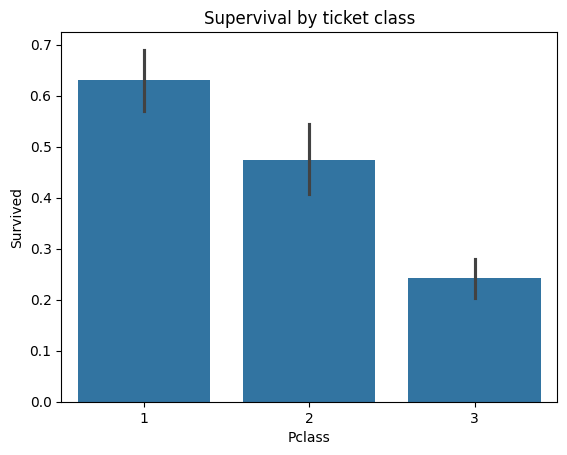

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


In [7]:
sns.barplot(x="Pclass", y="Survived", data=train)
plt.title("Supervival by ticket class")
plt.show()

# Specific percentages
print(train.groupby("Pclass")["Survived"].mean()*100)

### Age distribution

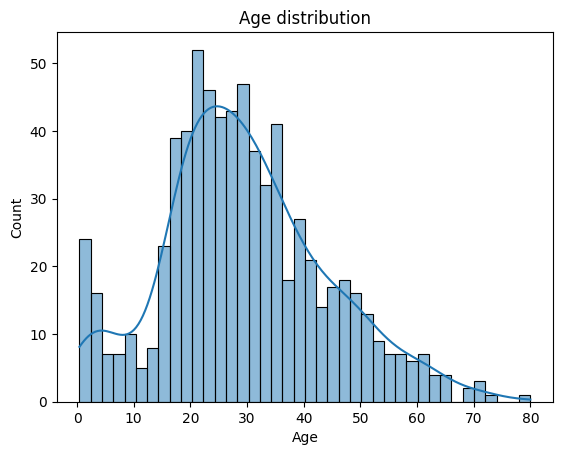

AgeGroup
Niño           57.971014
Adolescente    42.857143
Joven          38.268156
Adulto         40.000000
Anciano        22.727273
Name: Survived, dtype: float64


C:\Users\Sergio\AppData\Local\Temp\ipykernel_12968\3211621723.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(train.groupby("AgeGroup")["Survived"].mean()*100)


In [8]:
sns.histplot(train["Age"].dropna(), bins=40, kde=True)
plt.title("Age distribution")
plt.show()

# Average survival by age group
train["AgeGroup"] = pd.cut(train["Age"], bins=[0,12,18,35,60,80], labels=["Niño","Adolescente","Joven","Adulto","Anciano"])
print(train.groupby("AgeGroup")["Survived"].mean()*100)

### Family size distribution

#### Counting siblings and/or spouses on board

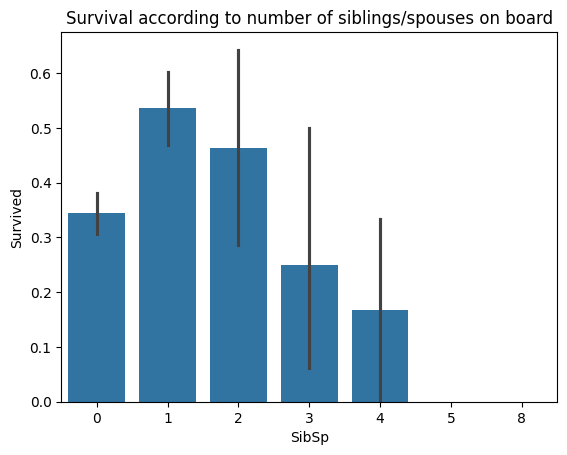

In [9]:
sns.barplot(x="SibSp", y="Survived", data=train)
plt.title("Survival according to number of siblings/spouses on board")
plt.show()

#### Counting parents/children on board

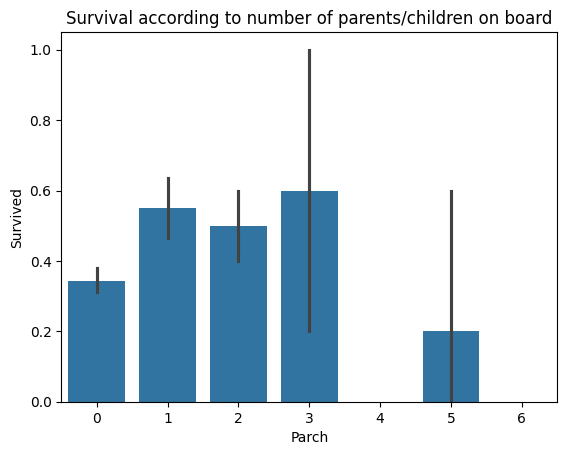

In [10]:
sns.barplot(x="Parch", y="Survived", data=train)
plt.title("Survival according to number of parents/children on board")
plt.show()

#### By total family size (spouses, children, siblings, parents, etc.)

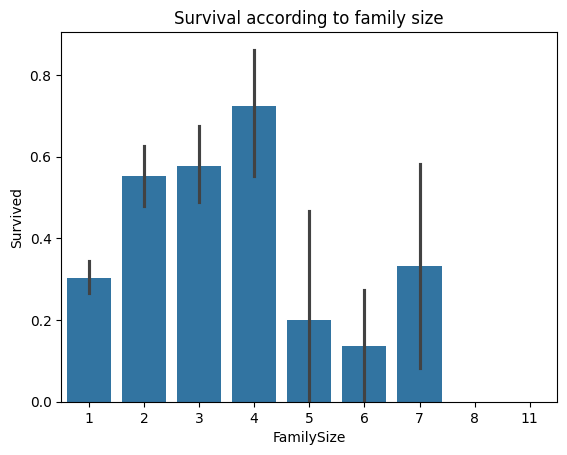

In [11]:
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1  
sns.barplot(x="FamilySize", y="Survived", data=train)
plt.title("Survival according to family size")
plt.show()

### TICKET PRICE DISTRIBUTION

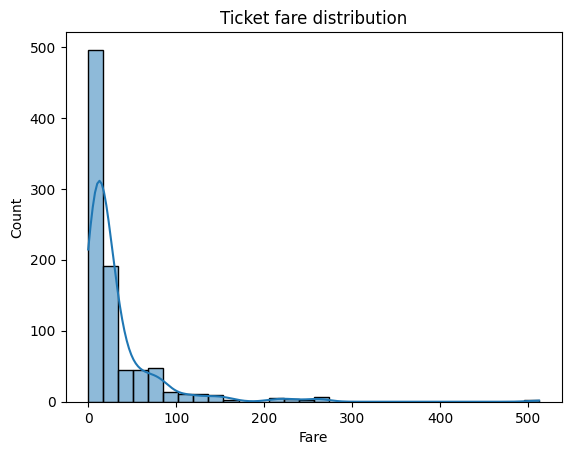

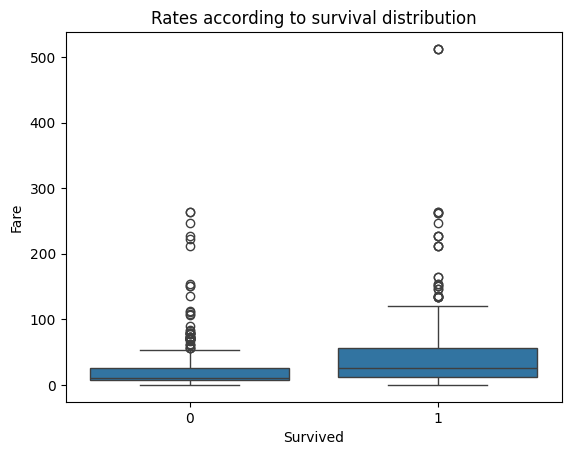

FareCustomGroup
0-7.85      21.686747
7.85-10     18.235294
10-15       38.524590
15-26       45.652174
26-50       41.481481
50-100      65.420561
100-275     72.000000
490-575    100.000000
Name: Survived, dtype: float64


C:\Users\Sergio\AppData\Local\Temp\ipykernel_12968\3583755891.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fare_survival_custom = train.groupby("FareCustomGroup")["Survived"].mean() * 100


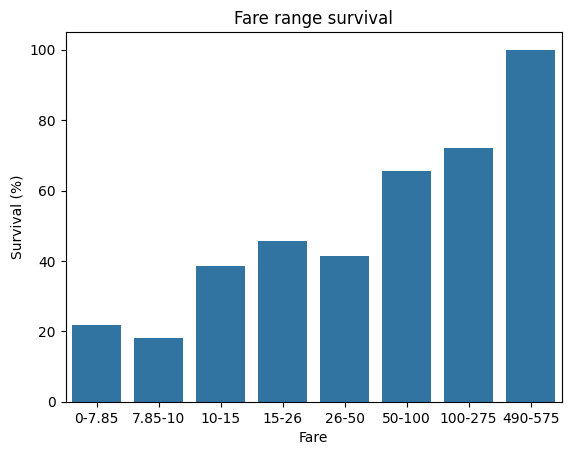

                 Passengers  Survival (%)
FareCustomGroup                          
0-7.85                  166     21.686747
7.85-10                 170     18.235294
10-15                   122     38.524590
15-26                   138     45.652174
26-50                   135     41.481481
50-100                  107     65.420561
100-275                  50     72.000000
490-575                   3    100.000000


In [12]:
# Tariff distribution
sns.histplot(train["Fare"], bins=30, kde=True)
plt.title("Ticket fare distribution")
plt.show()

# Fare boxplot for survival
sns.boxplot(x="Survived", y="Fare", data=train)
plt.title("Rates according to survival distribution")
plt.show()

# Divided by price ranges (quartiles are not representative)

bins = [0, 7.85, 10, 15, 26, 50, 100, 275, 575]
labels = ["0-7.85",  "7.85-10", "10-15", "15-26", "26-50", "50-100", "100-275", "490-575"]

# Create groups
train["FareCustomGroup"] = pd.cut(train["Fare"], bins=bins, labels=labels, include_lowest=True)

# Calculate survival by group
fare_survival_custom = train.groupby("FareCustomGroup")["Survived"].mean() * 100
print(fare_survival_custom)

# Plot
sns.barplot(x=fare_survival_custom.index, y=fare_survival_custom.values)
plt.title("Fare range survival")
plt.ylabel("Survival (%)")
plt.xlabel("Fare")
plt.show()


# Passenger count by price range
fare_counts = train["FareCustomGroup"].value_counts().sort_index()

# Combine with survival rate
fare_summary = pd.DataFrame({
    "Passengers": fare_counts,
    "Survival (%)": fare_survival_custom
})

print(fare_summary)

### Place of boarding distribution

Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64


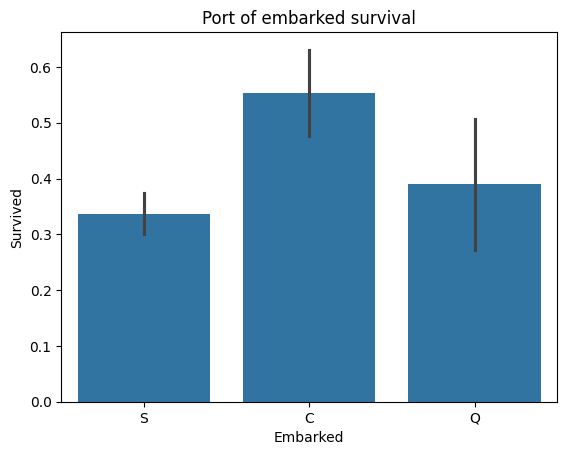

In [13]:
# Counting shipments
print(train["Embarked"].value_counts(dropna=False))

# Survival by port plot
sns.barplot(x="Embarked", y="Survived", data=train)
plt.title("Port of embarked survival")
plt.show()

### Cabin and deck distribution

In [14]:
# Null values
print("Null values in Cabin:", train["Cabin"].isnull().sum())
print("No null values in Cabin::", len(train["Cabin"]) - train["Cabin"].isnull().sum())

# Remove the letter from the booth 
train["CabinLetter"] = train["Cabin"].str[0]

# Survival rates per deck
print(train.groupby("CabinLetter")["Survived"].mean() * 100)

Null values in Cabin: 687
No null values in Cabin:: 204
CabinLetter
A    46.666667
B    74.468085
C    59.322034
D    75.757576
E    75.000000
F    61.538462
G    50.000000
T     0.000000
Name: Survived, dtype: float64


# LOGISTIC REGRESSION

## PREPARE THE DATA

In [15]:
# Copy
df = train.copy()

# Charges
df["Age"] = df["Age"].fillna(df["Age"].median())
emb_mode = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(emb_mode)
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

# Encoding
df["Sex"] = df["Sex"].map({"male": 0, "female": 1}).astype("int64")
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

# Features y target
features = ["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch",
            "Embarked_Q", "Embarked_S"]
X = df[features]
y = df["Survived"].astype("int64")

# Train/valid
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape, "| X_valid:", X_valid.shape)

X_train: (712, 8) | X_valid: (179, 8)


## TRAIN THE MODEL

In [16]:
# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_valid)

# Metrics
acc = accuracy_score(y_valid, y_pred)
print(f"Accuracy validación: {acc*100:.2f}%")

print("\nRanking report:")
print(classification_report(y_valid, y_pred, labels=[0,1],
                            target_names=["No sobrevivió","Sobrevivió"],
                            digits=3))

print("Confusion matrix [ [TN FP] [FN TP] ]:")
print(confusion_matrix(y_valid, y_pred, labels=[0,1]))

Accuracy validación: 80.45%

Ranking report:
               precision    recall  f1-score   support

No sobrevivió      0.810     0.891     0.848       110
   Sobrevivió      0.793     0.667     0.724        69

     accuracy                          0.804       179
    macro avg      0.802     0.779     0.786       179
 weighted avg      0.803     0.804     0.801       179

Confusion matrix [ [TN FP] [FN TP] ]:
[[98 12]
 [23 46]]


## REGRESSION COEFFICIENTS

In [17]:
# Obtain coefficients

coef = model.coef_[0]                                       
features = X_train.columns                                  

# Table
coef_table = pd.DataFrame({
    "Variable": features,
    "Coefficient": coef,
    "Impact": np.exp(coef)                                 # Odds ratio
}).sort_values(by="Coefficient", ascending=False)

print(coef_table)

     Variable  Coefficient     Impact
1         Sex     2.559387  12.927890
6  Embarked_Q     0.279164   1.322025
3        Fare     0.002239   1.002241
2         Age    -0.038567   0.962167
5       Parch    -0.071126   0.931345
4       SibSp    -0.244579   0.783034
7  Embarked_S    -0.381360   0.682932
0      Pclass    -1.092261   0.335457


#   RANDOM FOREST

## MODEL

In [18]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_valid)
y_proba_rf = rf.predict_proba(X_valid)[:, 1]

acc_rf = accuracy_score(y_valid, y_pred_rf)
auc_rf = roc_auc_score(y_valid, y_proba_rf)

print(f"Accuracy validación (RF): {acc_rf*100:.2f}%")
print(f"ROC-AUC (RF): {auc_rf:.3f}\n")

print("Ranking report (RF):")
print(classification_report(y_valid, y_pred_rf, labels=[0,1],
                            target_names=["No sobrevivió","Sobrevivió"],
                            digits=3))

print("Confusion matrix [ [TN FP] [FN TP] ] (RF):")
print(confusion_matrix(y_valid, y_pred_rf, labels=[0,1]))

# Importance of variables
imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Importance of characteristics (RF):")
print(imp)

Accuracy validación (RF): 81.01%
ROC-AUC (RF): 0.835

Ranking report (RF):
               precision    recall  f1-score   support

No sobrevivió      0.828     0.873     0.850       110
   Sobrevivió      0.778     0.710     0.742        69

     accuracy                          0.810       179
    macro avg      0.803     0.791     0.796       179
 weighted avg      0.808     0.810     0.808       179

Confusion matrix [ [TN FP] [FN TP] ] (RF):
[[96 14]
 [20 49]]
Importance of characteristics (RF):
Fare          0.276436
Sex           0.259792
Age           0.248427
Pclass        0.088870
SibSp         0.050154
Parch         0.040666
Embarked_S    0.026303
Embarked_Q    0.009351
dtype: float64


### Hyperparameter tuning

In [20]:
# Define the base model
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Define the parameter grid
param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# Configure GridSearchCV
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                  
    scoring="roc_auc",  
    n_jobs=-1,
    verbose=2
)

# Training the search
grid.fit(X_train, y_train)

print("Best parameters found:", grid.best_params_)
print("Best AUC in cross-validation:", grid.best_score_)

# Optimised model
best_rf = grid.best_estimator_

# Evaluate in the validation set
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

y_pred_best = best_rf.predict(X_valid)
y_proba_best = best_rf.predict_proba(X_valid)[:,1]

print(f"Accuracy validation (best RF): {accuracy_score(y_valid, y_pred_best)*100:.2f}%")
print(f"ROC-AUC validation (best RF): {roc_auc_score(y_valid, y_proba_best):.3f}\n")

print("Ranking report (best RF):")
print(classification_report(y_valid, y_pred_best, digits=3))

print(" Confusion matrix (best RF):")
print(confusion_matrix(y_valid, y_pred_best))

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best parameters found: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best AUC in cross-validation: 0.8789633930738946
Accuracy validation (best RF): 81.01%
ROC-AUC validation (best RF): 0.837

Ranking report (best RF):
              precision    recall  f1-score   support

           0      0.802     0.918     0.856       110
           1      0.830     0.638     0.721        69

    accuracy                          0.810       179
   macro avg      0.816     0.778     0.789       179
weighted avg      0.813     0.810     0.804       179

 Confusion matrix (best RF):
[[101   9]
 [ 25  44]]


#   GRADIENT BOOSTING 

## Model

In [21]:
gb = GradientBoostingClassifier(
    n_estimators=200,      # árboles
    learning_rate=0.05,   # paso del gradiente
    max_depth=3,          # profundidad de cada árbol débil
    subsample=0.8,        # Stochastic GB (ayuda a generalizar)
    random_state=42
)

gb.fit(X_train, y_train)
y_pred_gb  = gb.predict(X_valid)
y_proba_gb = gb.predict_proba(X_valid)[:, 1]

print(f"Accuracy validación (GB): {accuracy_score(y_valid, y_pred_gb)*100:.2f}%")
print(f"ROC-AUC (GB): {roc_auc_score(y_valid, y_proba_gb):.3f}\n")

print("Classification report(GB):")
print(classification_report(y_valid, y_pred_gb, digits=3))

print("Confusion matrix (GB):")
print(confusion_matrix(y_valid, y_pred_gb))

gb_imp = pd.Series(gb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Importances (GB):")
print(gb_imp)

# Fast tuning
gb_base = GradientBoostingClassifier(random_state=42)

param_dist = {
    "n_estimators":   [150, 200, 300, 400],
    "learning_rate":  [0.02, 0.03, 0.05, 0.08, 0.1],
    "max_depth":      [2, 3, 4],
    "subsample":      [0.7, 0.8, 1.0],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":   [None, "sqrt", "log2"]
}

rs = RandomizedSearchCV(
    gb_base,
    param_distributions=param_dist,
    n_iter=40,            
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rs.fit(X_train, y_train)
print("Best parameters (GB):", rs.best_params_)
print("Best AUC CV (GB):", rs.best_score_)

gb_best = rs.best_estimator_
y_pred_best = gb_best.predict(X_valid)
y_proba_best = gb_best.predict_proba(X_valid)[:, 1]

print(f"\nAccuracy validation (GB best): {accuracy_score(y_valid, y_pred_best)*100:.2f}%")
print(f"ROC-AUC validation (GB best): {roc_auc_score(y_valid, y_proba_best):.3f}")
print("\nRanking report (GB best):")
print(classification_report(y_valid, y_pred_best, digits=3))
print("Confusion matrix (GB best):")
print(confusion_matrix(y_valid, y_pred_best))

Accuracy validación (GB): 79.89%
ROC-AUC (GB): 0.811

Classification report(GB):
              precision    recall  f1-score   support

           0      0.798     0.900     0.846       110
           1      0.800     0.638     0.710        69

    accuracy                          0.799       179
   macro avg      0.799     0.769     0.778       179
weighted avg      0.799     0.799     0.794       179

Confusion matrix (GB):
[[99 11]
 [25 44]]
Importances (GB):
Sex           0.405830
Fare          0.218748
Age           0.168563
Pclass        0.137557
SibSp         0.031480
Embarked_S    0.026184
Parch         0.009309
Embarked_Q    0.002328
dtype: float64
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best parameters (GB): {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 2, 'learning_rate': 0.05}
Best AUC CV (GB): 0.8818841893332487

Accuracy validation (GB best): 81.56%
ROC-AUC validation (GB b

### Treshold adjustment

In [22]:
def eval_umbral(probas, y_true, thr):
    preds = (probas >= thr).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_true, preds, average="binary")
    return p, r, f1

probas = y_proba_gb 
mejor = (0, 0, 0, 0) 

for thr in np.linspace(0.3, 0.6, 13):
    p, r, f1 = eval_umbral(probas, y_valid, thr)
    if f1 > mejor[3]:
        mejor = (thr, p, r, f1)

print(f"Best threshold for F1 class 1: {mejor[0]:.2f} | P={mejor[1]:.3f} R={mejor[2]:.3f} F1={mejor[3]:.3f}")

Best threshold for F1 class 1: 0.40 | P=0.797 R=0.739 F1=0.767


# TEST THE MODEL WITH TEST.CSV 

In [23]:
# Load raw data
train_raw = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")

# Statistics for crude train only
age_median  = train_raw["Age"].median()
fare_median = train_raw["Fare"].median()
emb_mode    = train_raw["Embarked"].mode()[0]

# Imputations in tests with train statistics
test_df["Age"]  = test_df["Age"].fillna(age_median)
test_df["Fare"] = test_df["Fare"].fillna(fare_median)
test_df["Embarked"] = test_df["Embarked"].fillna(emb_mode)

# Encoding as in train
test_df["Sex"] = test_df["Sex"].map({"male": 0, "female": 1}).astype("int64")
test_df = pd.get_dummies(test_df, columns=["Embarked"], drop_first=True)

# Ensure that the same dummy columns we used in train exist
for col in ["Embarked_Q", "Embarked_S"]:
    if col not in test_df.columns:
        test_df[col] = 0

# Same trained features
features = ["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch",
            "Embarked_Q", "Embarked_S"]
X_test = test_df[features]

# Predictions with the best Gradient Boost model 
y_test_proba = gb_best.predict_proba(X_test)[:, 1]
y_test_pred_thr = (y_test_proba >= 0.40).astype(int)

# Create and save submission
submission_thr = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": y_test_pred_thr
})
submission_thr.to_csv("submission_gb_thr040.csv", index=False)

print("File 'submission_gb_thr040.csv' ")


File 'submission_gb_thr040.csv' 
